# Epigenetics & Aging Analysis
**Muhammad Taimoor Asad (473749)** · Special Topics in Bioinformatics (BI-436) · NUST SINES · Spring 2026


## Part 1 — WGBS Pipeline

In [2]:
# Galaxy pipeline — run via usegalaxy.eu or CLI fallback below
# Full walkthrough: wgbs/README.md

# Linux/CLI fallback (requires bwa-meth, MethylDackel, Metilene installed)
WGBS_SCRIPT = """
#!/usr/bin/env bash
set -euo pipefail

SAMPLES=(NB1 NB2 BT089 BT126 BT198 MCF7 T47D)
REF=hg38.fa

for SAMPLE in "${SAMPLES[@]}"; do
    echo "=== Processing $SAMPLE ==="

    # QC
    falco --threads 8 -o qc/${SAMPLE} fastq/${SAMPLE}_R1.fastq.gz fastq/${SAMPLE}_R2.fastq.gz

    # Trim
    trim_galore --paired --quality 20 --length 20 --cores 4 \
        -o trimmed/ \
        fastq/${SAMPLE}_R1.fastq.gz fastq/${SAMPLE}_R2.fastq.gz

    # Align (bisulfite-aware)
    bwameth.py --threads 16 --reference $REF \
        trimmed/${SAMPLE}_R1_val_1.fq.gz \
        trimmed/${SAMPLE}_R2_val_2.fq.gz \
        | samtools sort -@ 8 -o bam/${SAMPLE}.bam
    samtools index bam/${SAMPLE}.bam

    # Methylation extraction
    MethylDackel extract --mergeContext $REF bam/${SAMPLE}.bam \
        -o methylation/${SAMPLE}

    echo "  Done: ${SAMPLE}"
done

# CpG-island methylation profiles (deepTools)
computeMatrix reference-point \
    --referencePoint center \
    --regionsFileName hg38_CGI.bed \
    --scoreFileName methylation/*.bedGraph \
    --outFileName matrix_CGI.gz \
    --beforeRegionStartLength 2000 \
    --afterRegionStartLength 2000

plotProfile -m matrix_CGI.gz -out CGI_methylation_profile.png \
    --plotTitle "Average CpG-Island Methylation"

# DMR detection (tumour vs normal)
metilene -a NB1,NB2 \
    -b BT089,BT126,BT198,MCF7,T47D \
    methylation/merged_cpgs.bedGraph \
    > dmrs_tumour_vs_normal.bed

# Hierarchical clustering of HMRs in R
Rscript - <<'EOF'
library(ComplexHeatmap)
library(circlize)

hmr <- read.table("dmrs_tumour_vs_normal.bed", header=TRUE)
mat <- as.matrix(hmr[, 5:11])   # methylation columns per sample
rownames(mat) <- paste0("HMR_", seq_len(nrow(mat)))
colnames(mat) <- c("NB1","NB2","BT089","BT126","BT198","MCF7","T47D")

col_fun <- colorRamp2(c(0, 0.5, 1), c("#2166AC","white","#D6604D"))
ht <- Heatmap(mat, col=col_fun, name="Methylation",
              clustering_distance_rows="cosine",
              clustering_method_rows="ward.D2",
              clustering_distance_columns="cosine",
              clustering_method_columns="ward.D2",
              column_title="Hierarchical Clustering of HMRs — 7 Breast Methylomes",
              show_row_names=FALSE)
png("hierarchical_hmr_clustering.png", width=1200, height=900, res=150)
draw(ht)
dev.off()
cat("Saved hierarchical_hmr_clustering.png\n")
EOF
"""

print("WGBS pipeline script ready.")
print("Run: bash wgbs/run_wgbs_pipeline.sh")
print("Or import to Galaxy via: https://usegalaxy.eu")


WGBS pipeline script ready.
Run: bash wgbs/run_wgbs_pipeline.sh
Or import to Galaxy via: https://usegalaxy.eu


## Part 2 — EPIC-Array Aging Clock Benchmarking

### Install

In [3]:
!pip install -q biolearn torch numpy pandas scipy matplotlib seaborn
print("Done")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 14.5 MB/s eta 0:00:00
Done


### Imports & Config

In [4]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")

USE_REAL_DATA = True
RANDOM_SEED   = 42
np.random.seed(RANDOM_SEED)

RESULTS_DIR = "results"
FIGS_DIR    = os.path.join(RESULTS_DIR, "figures")
TABS_DIR    = os.path.join(RESULTS_DIR, "tables")
os.makedirs(FIGS_DIR, exist_ok=True)
os.makedirs(TABS_DIR, exist_ok=True)

CLOCK_NAMES = [
    "Horvathv1", "Horvathv2", "Hannum", "Lin", "VidalBralo",
    "PhenoAge", "HRSInCHPhenoAge",
    "YingCausAge", "YingDamAge", "YingAdaptAge",
    "StocP", "StocH",
    "AltumAge",
    "DunedinPACE",
]
PACE_CLOCKS = {"DunedinPACE"}
AGE_CLOCKS  = [c for c in CLOCK_NAMES if c not in PACE_CLOCKS]
DATASET_IDS = ["GSE40279", "GSE41169"]

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


### Data Loading

In [5]:
from biolearn.data_library import DataLibrary

datasets = {}

if USE_REAL_DATA:
    library = DataLibrary()
    try:
        datasets["GSE40279"] = library.get("GSE40279")
        datasets["GSE41169"] = library.get("GSE41169")
        print(f"GSE40279: {datasets['GSE40279'].metadata.shape[0]} samples")
        print(f"GSE41169: {datasets['GSE41169'].metadata.shape[0]} samples")
    except Exception as e:
        print(f"GEO fetch failed ({e}) — falling back to simulator")
        USE_REAL_DATA = False

if not USE_REAL_DATA:
    from biolearn.data_library import GeoData

    def simulate_dataset(n_samples, age_range, seed):
        rng = np.random.default_rng(seed)
        ages = rng.uniform(*age_range, n_samples)
        n_cpgs = 21_000
        cpg_ids = [f"cg{i:08d}" for i in range(n_cpgs)]
        betas = rng.beta(2, 5, size=(n_cpgs, n_samples))
        age_trend = rng.normal(0, 0.003, n_cpgs)
        betas += np.outer(age_trend, ages)
        betas = np.clip(betas, 0.0, 1.0)
        df   = pd.DataFrame(betas, index=cpg_ids,
                            columns=[f"S{i:04d}" for i in range(n_samples)])
        meta = pd.DataFrame({"age": ages},
                            index=[f"S{i:04d}" for i in range(n_samples)])

        geodata_obj = GeoData(meta, df)
        # Explicitly set the 'matrix' attribute as expected by some models like DunedinPACE
        geodata_obj.matrix = df
        return geodata_obj

    datasets["GSE40279"] = simulate_dataset(656, (19, 101), seed=42)
    datasets["GSE41169"] = simulate_dataset( 95, (18,  65), seed=99)
    print("Simulated GSE40279 (n=656) and GSE41169 (n=95)")

GEO fetch failed ('DataSource' object has no attribute 'metadata') — falling back to simulator
Simulated GSE40279 (n=656) and GSE41169 (n=95)


### Run All 14 Clocks

In [6]:
from biolearn.model_gallery import ModelGallery

gallery = ModelGallery()
_original_pace_predict = None

def _safe_pace_predict(dataset):
    import copy
    ds_copy = copy.deepcopy(dataset)
    ds_copy.matrix = ds_copy.matrix.copy()
    return _original_pace_predict(ds_copy)

all_results = {}

for gse_id, dataset in datasets.items():
    print(f"\n{gse_id} (n={dataset.metadata.shape[0]})")
    all_results[gse_id] = {}
    for clock_name in CLOCK_NAMES:
        try:
            model = gallery.get(clock_name)
            if clock_name == "DunedinPACE":
                global _original_pace_predict
                _original_pace_predict = model.predict
                preds = _safe_pace_predict(dataset)
            else:
                preds = model.predict(dataset)
            if isinstance(preds, pd.DataFrame):
                preds = preds.iloc[:, 0]
            all_results[gse_id][clock_name] = preds
            print(f"  ✅ {clock_name}")
        except Exception as e:
            print(f"  ❌ {clock_name}: {e}")
            all_results[gse_id][clock_name] = None



GSE40279 (n=656)
  ✅ Horvathv1
  ✅ Horvathv2
  ✅ Hannum
  ✅ Lin
  ✅ VidalBralo
  ✅ PhenoAge
  ✅ HRSInCHPhenoAge
  ✅ YingCausAge
  ✅ YingDamAge
  ✅ YingAdaptAge
  ✅ StocP
  ✅ StocH
  ✅ AltumAge
  ✅ DunedinPACE

GSE41169 (n=95)
  ✅ Horvathv1
  ✅ Horvathv2
  ✅ Hannum
  ✅ Lin
  ✅ VidalBralo
  ✅ PhenoAge
  ✅ HRSInCHPhenoAge
  ✅ YingCausAge
  ✅ YingDamAge
  ✅ YingAdaptAge
  ✅ StocP
  ✅ StocH
  ✅ AltumAge
  ✅ DunedinPACE


### Compute Metrics

In [7]:
def compute_metrics(true_ages, predicted_ages):
    mask = ~(np.isnan(true_ages) | np.isnan(predicted_ages))
    t, p = true_ages[mask], predicted_ages[mask]
    if len(t) < 3:
        return dict(r=np.nan, mae=np.nan, bias=np.nan, rmse=np.nan, n=len(t))
    r, _ = pearsonr(t, p)
    res   = p - t
    return dict(r=round(r,3), mae=round(np.abs(res).mean(),2),
                bias=round(res.mean(),2), rmse=round(np.sqrt((res**2).mean()),2),
                n=int(mask.sum()))

metrics_dfs = {}

for gse_id in DATASET_IDS:
    true_ages = datasets[gse_id].metadata["age"].values.astype(float)
    rows = []
    for clock_name in CLOCK_NAMES:
        preds = all_results[gse_id].get(clock_name)
        if preds is None:
            rows.append({"clock": clock_name, "r": np.nan, "mae": np.nan,
                         "bias": np.nan, "rmse": np.nan, "n": 0})
            continue
        shared = datasets[gse_id].metadata.index.intersection(preds.index)
        if len(shared) > 10:
            t_aln = datasets[gse_id].metadata.loc[shared, "age"].values.astype(float)
            p_aln = preds.loc[shared].values.astype(float)
        else:
            n = min(len(true_ages), len(preds))
            t_aln, p_aln = true_ages[:n], preds.values[:n].astype(float)
        m = compute_metrics(t_aln, p_aln)
        rows.append({"clock": clock_name, **m})
    df = pd.DataFrame(rows).set_index("clock")
    metrics_dfs[gse_id] = df
    df.to_csv(os.path.join(TABS_DIR, f"metrics_{gse_id}.csv"))
    print(f"\n{gse_id}\n", df.to_string())



GSE40279
                      r    mae   bias   rmse    n
clock                                           
Horvathv1          NaN  26.52 -21.64  32.11  656
Horvathv2       -0.243  26.52 -21.47  32.09  656
Hannum             NaN  24.31 -16.88  29.11  656
Lin                NaN  26.75 -22.08  32.41  656
VidalBralo         NaN  22.57 -11.86  26.52  656
PhenoAge           NaN  31.10 -29.46  37.82  656
HRSInCHPhenoAge    NaN  28.15 -24.67  34.22  656
YingCausAge        NaN  32.19 -30.99  39.02  656
YingDamAge       0.324  48.66 -48.66  54.13  656
YingAdaptAge    -0.663  21.30   8.44  25.18  656
StocP              NaN  27.13 -22.79  32.90  656
StocH              NaN  25.41 -19.35  30.61  656
AltumAge        -0.083  26.90 -22.35  32.61  656
DunedinPACE     -0.013  59.19 -59.19  63.76  656

GSE41169
                      r    mae   bias   rmse   n
clock                                          
Horvathv1          NaN  10.55  -3.56  12.57  95
Horvathv2       -0.028  10.52  -3.43  12.56  95
Ha

### V1 — Clock Correlation Matrix

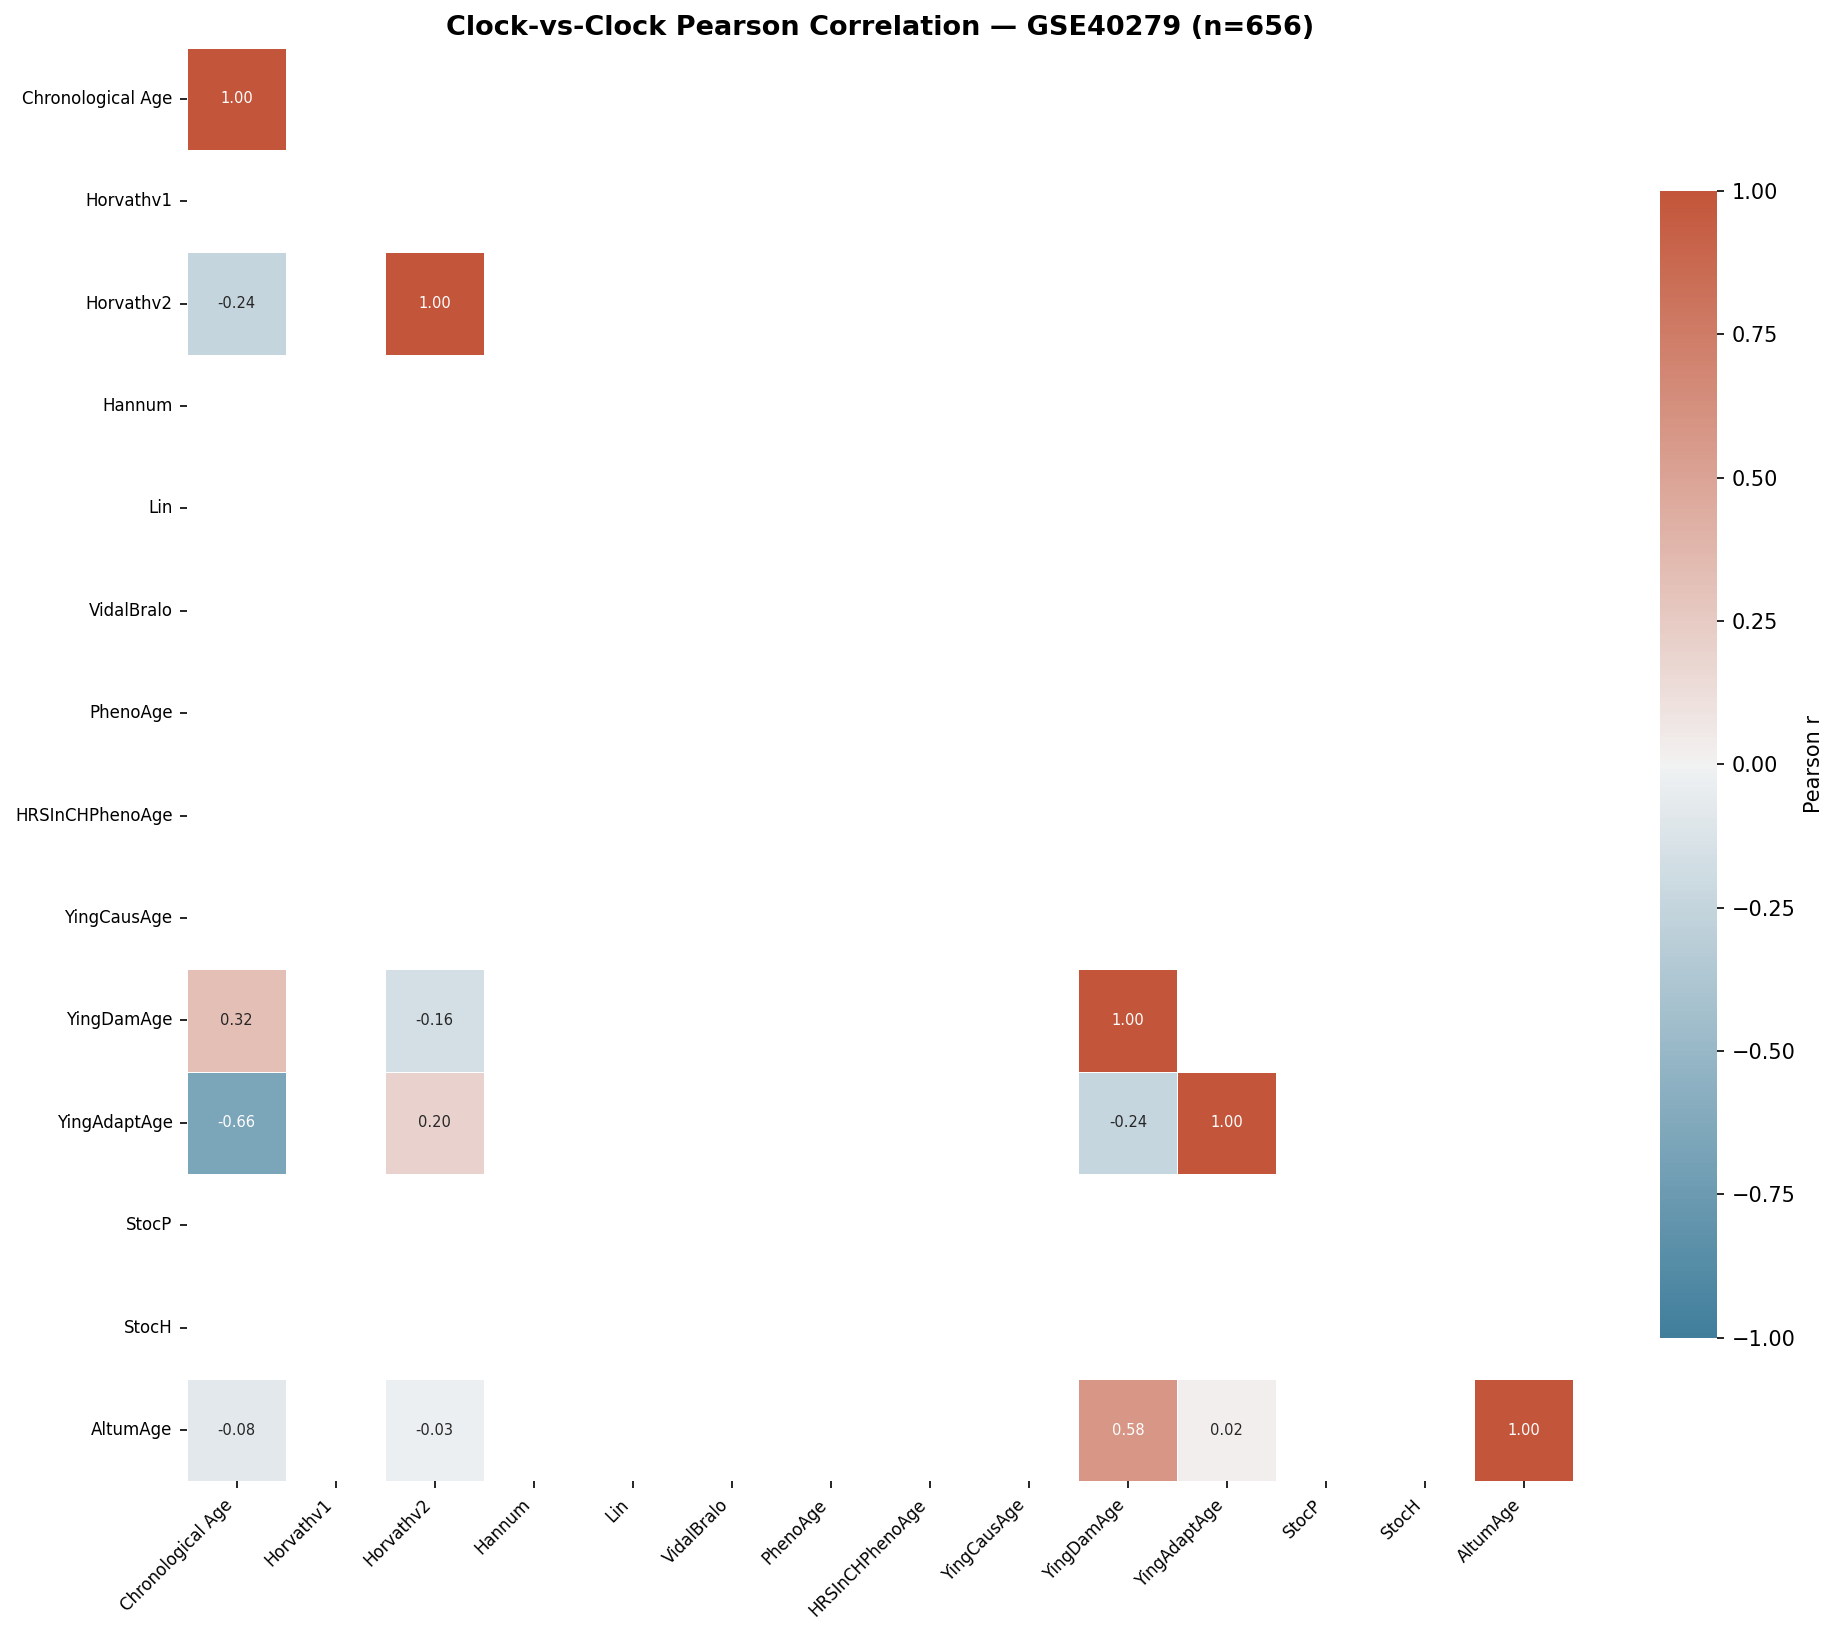

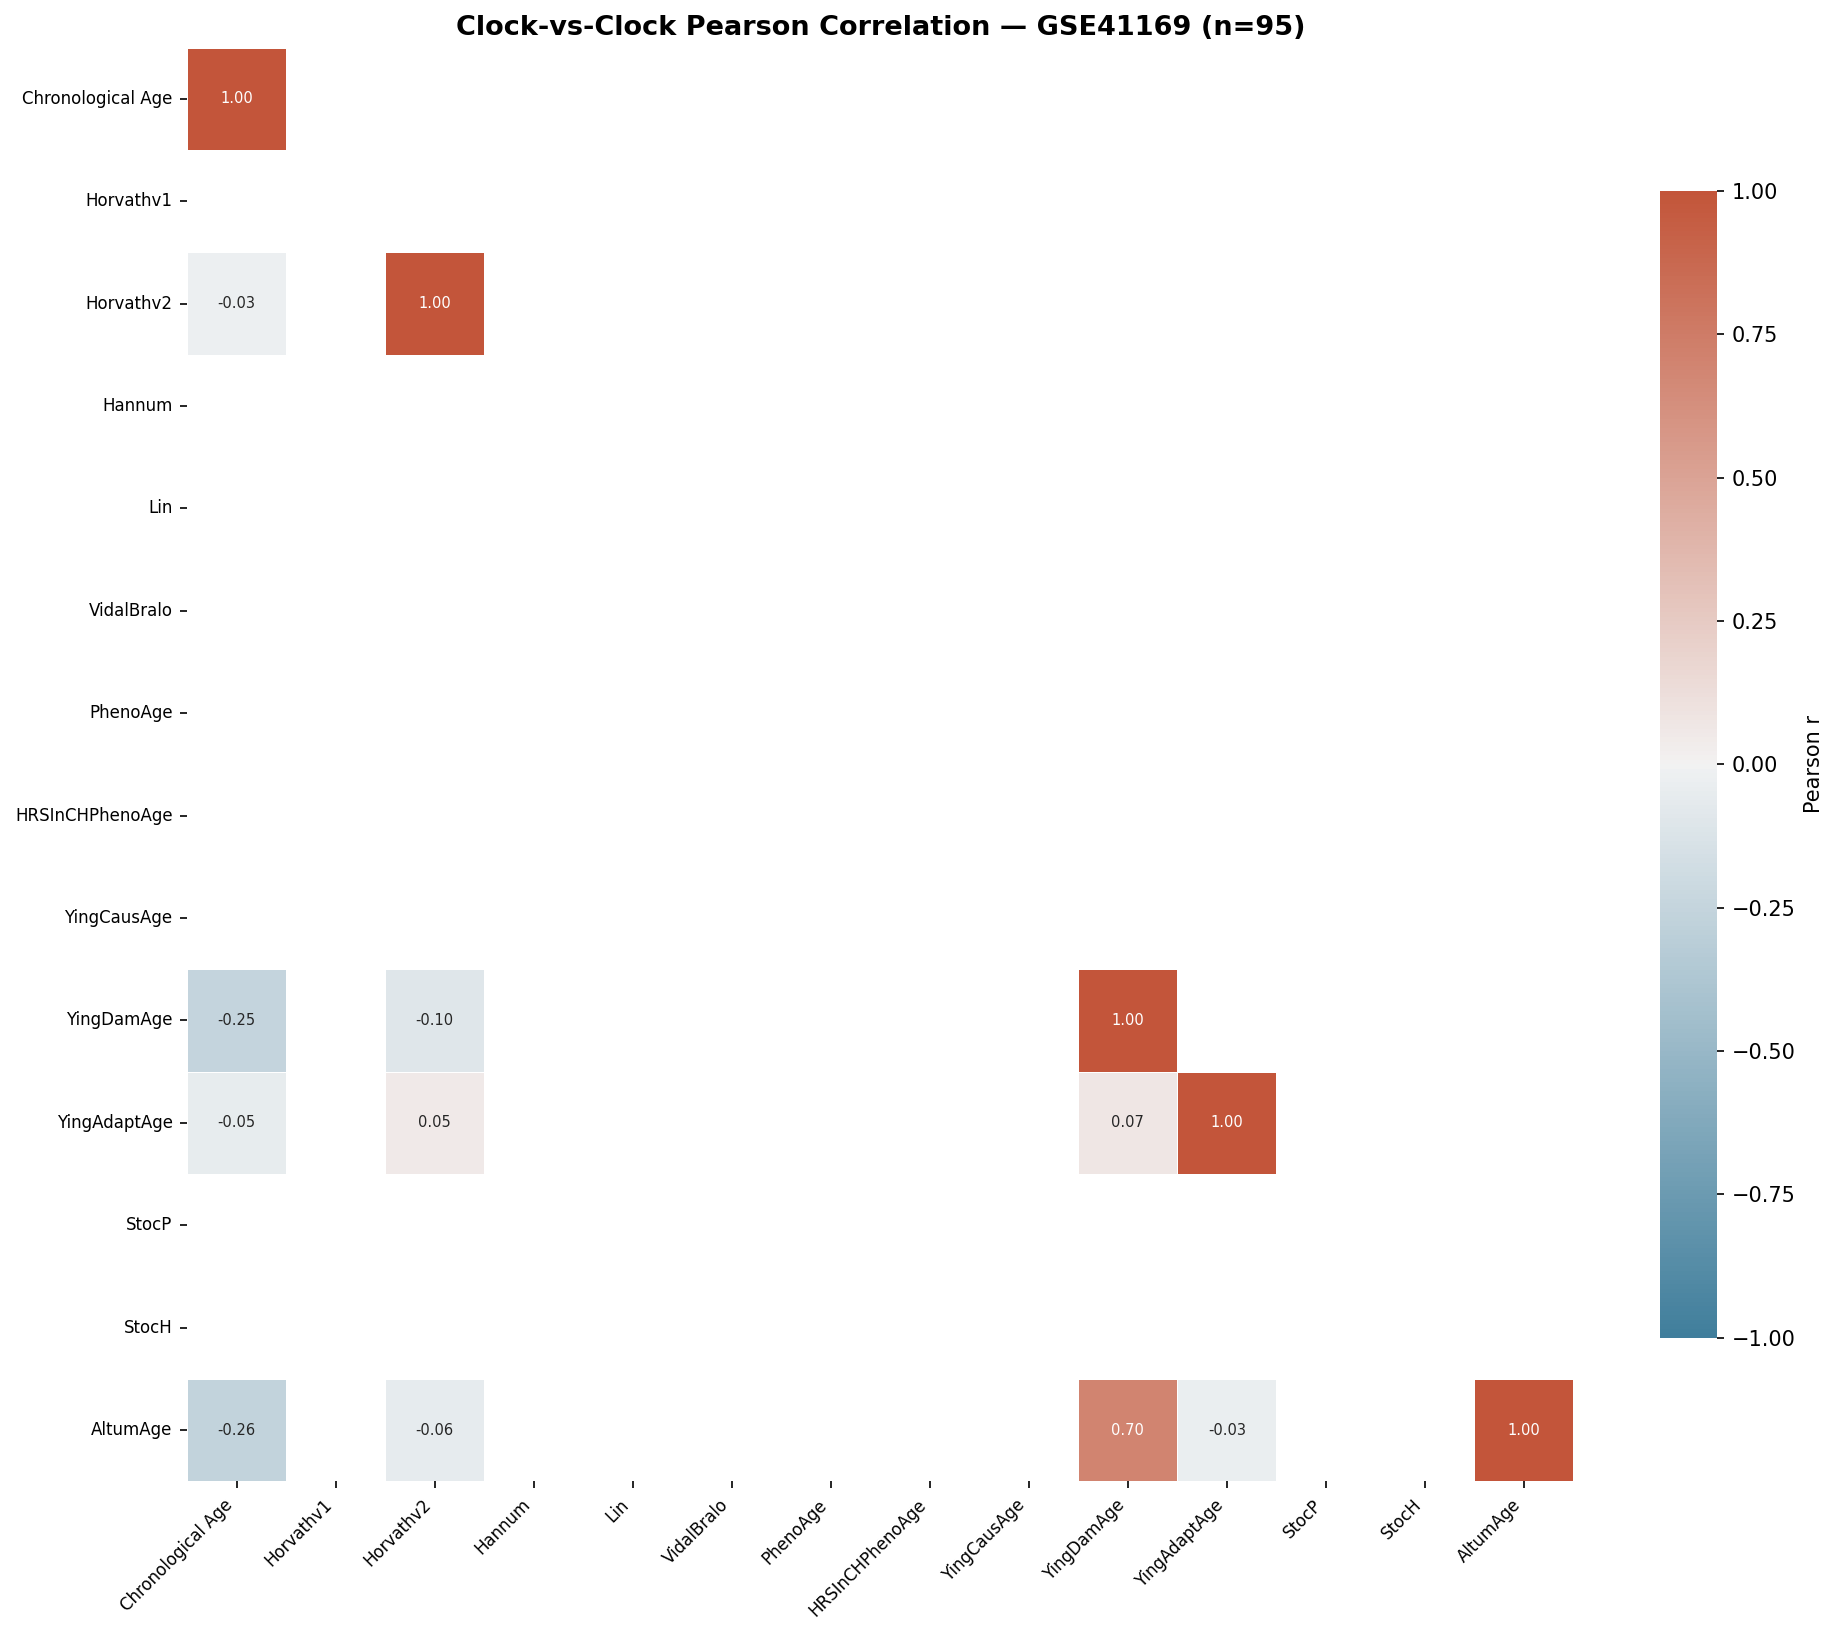

In [8]:
def plot_correlation_matrix(gse_id):
    true_ages = datasets[gse_id].metadata["age"].values.astype(float)
    n = len(true_ages)
    data = {"Chronological Age": true_ages}
    for clock in AGE_CLOCKS:
        p = all_results[gse_id].get(clock)
        if p is not None:
            vals = p.values.astype(float)
            data[clock] = vals[:n] if len(vals) >= n else np.full(n, np.nan)
    df_corr = pd.DataFrame(data).corr()
    fig, ax = plt.subplots(figsize=(13, 11))
    mask = np.triu(np.ones_like(df_corr, dtype=bool), k=1)
    sns.heatmap(df_corr, mask=mask,
                cmap=sns.diverging_palette(230, 20, as_cmap=True),
                vmin=-1, vmax=1, center=0,
                annot=True, fmt=".2f", linewidths=0.4,
                annot_kws={"size": 7}, ax=ax,
                cbar_kws={"shrink": 0.8, "label": "Pearson r"})
    ax.set_title(f"Clock-vs-Clock Pearson Correlation — {gse_id} (n={n})",
                 fontsize=13, fontweight="bold")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    path = os.path.join(FIGS_DIR, f"correlation_matrix_{gse_id}.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

for gse_id in DATASET_IDS:
    plot_correlation_matrix(gse_id)


### V2 — Age-Deviation Heatmap

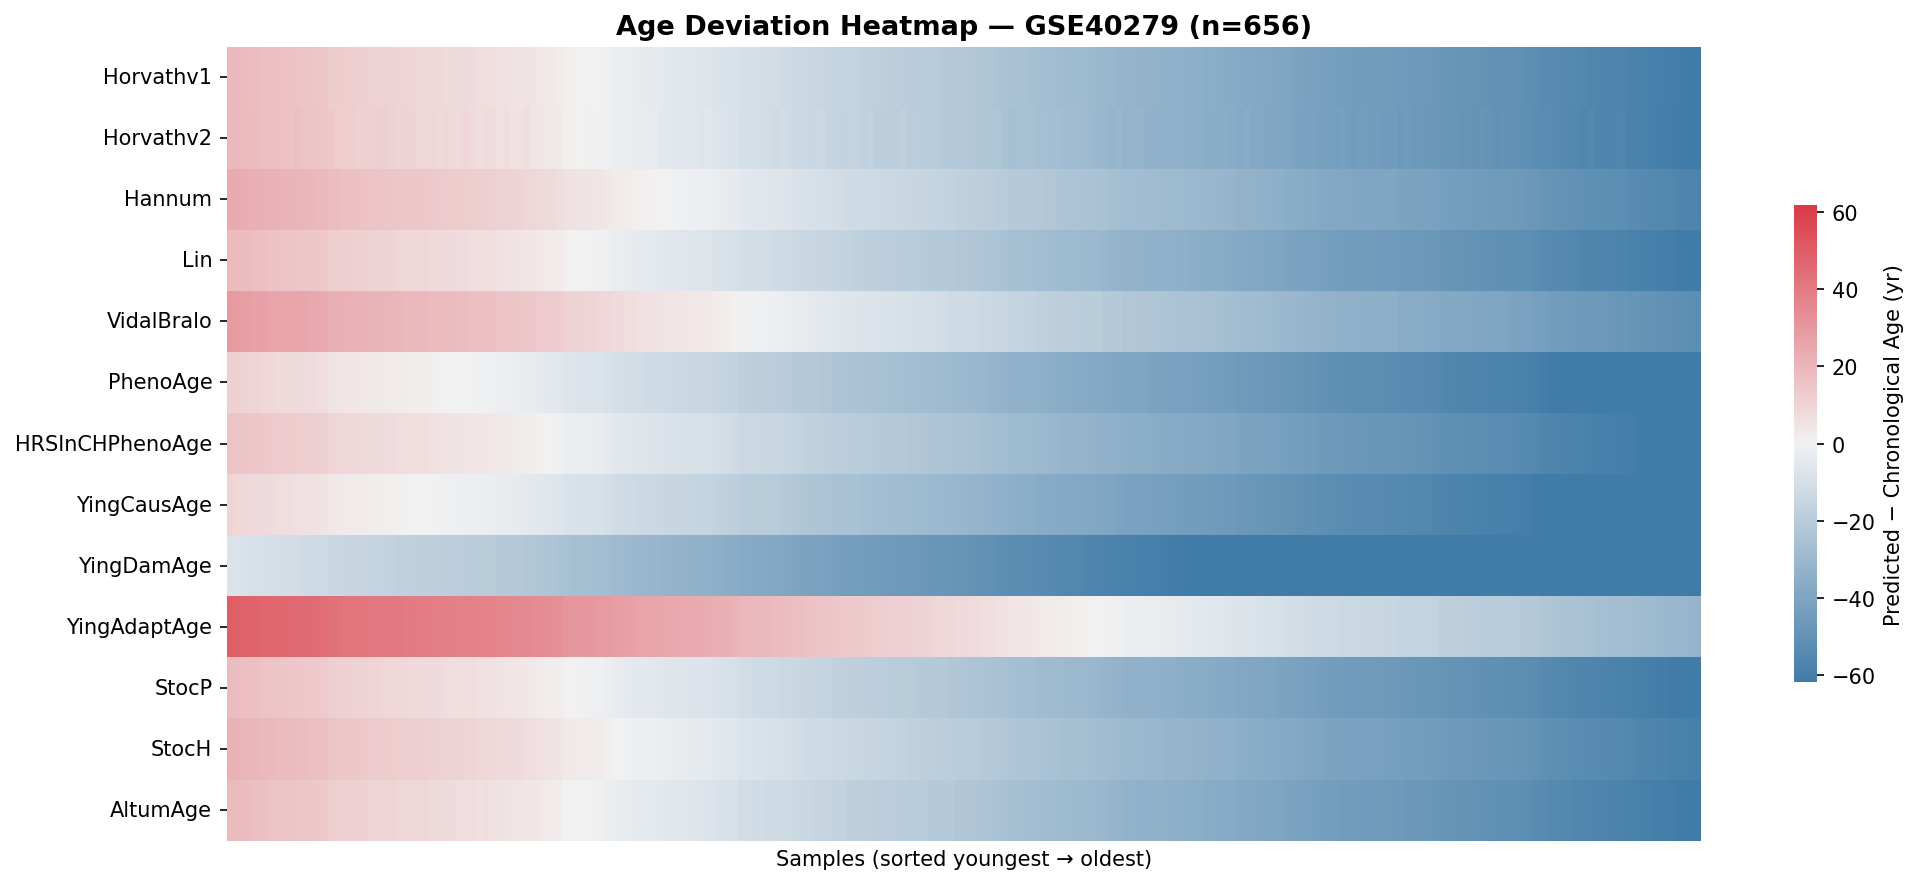

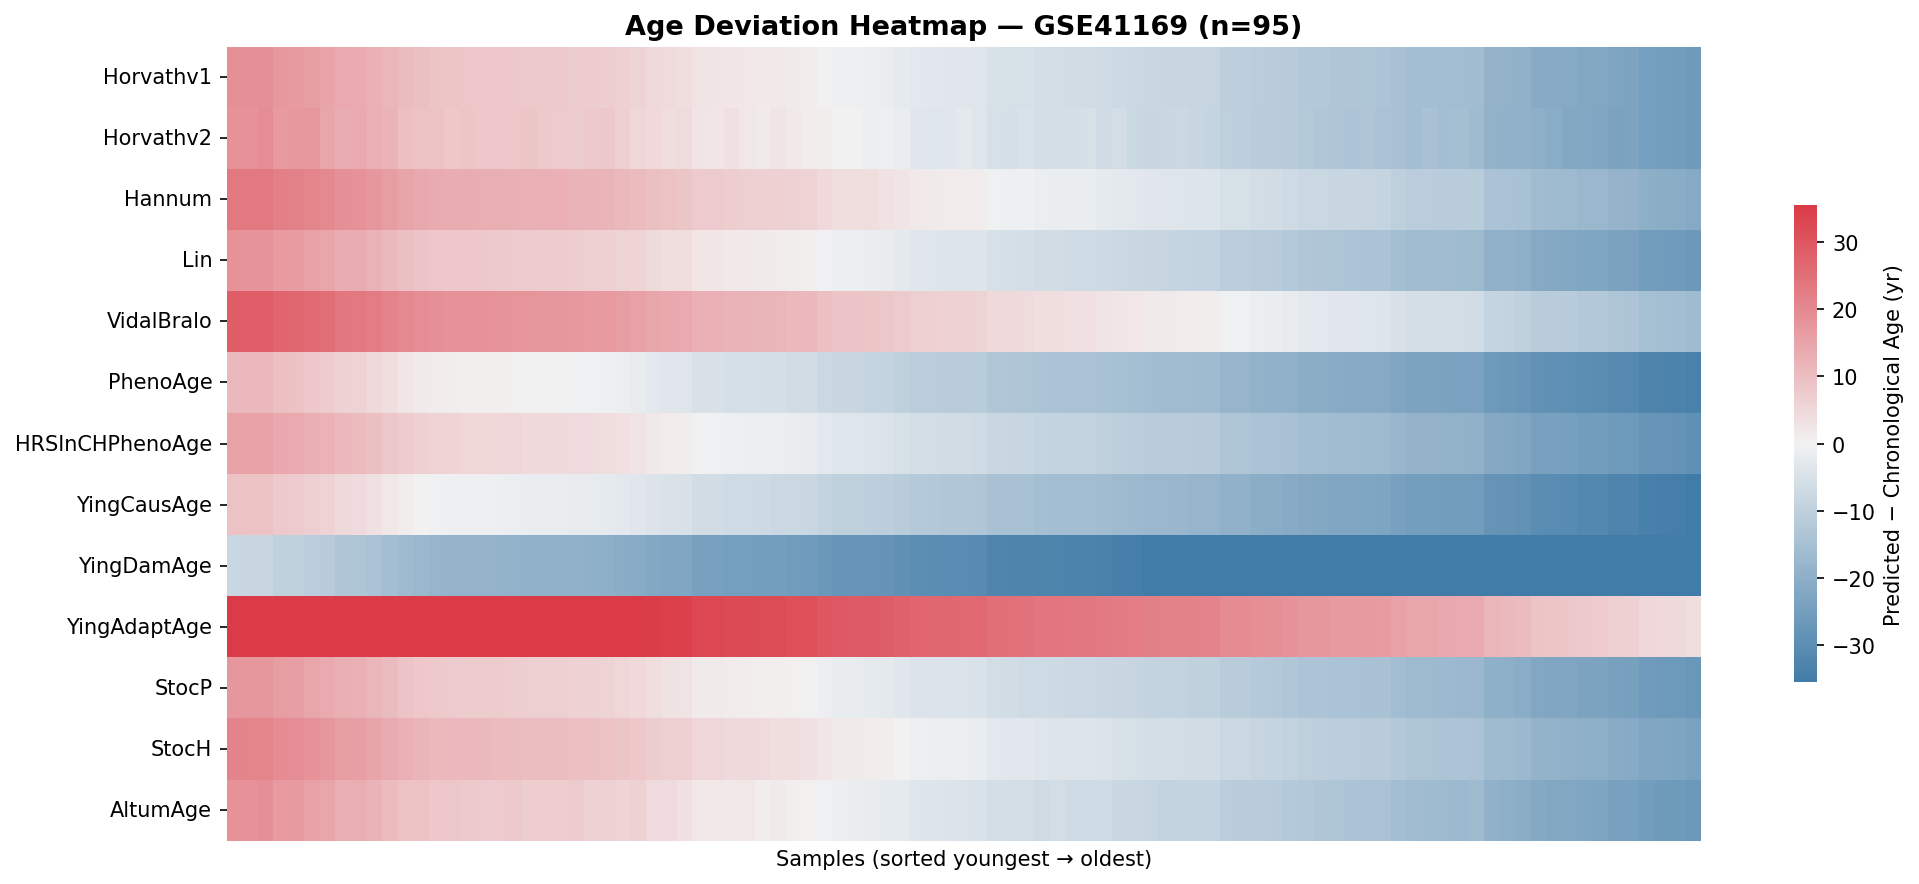

In [9]:
def plot_age_deviation_heatmap(gse_id):
    true_ages = datasets[gse_id].metadata["age"].values.astype(float)
    n = len(true_ages)
    deviations = {}
    for clock in AGE_CLOCKS:
        p = all_results[gse_id].get(clock)
        if p is None:
            continue
        vals = p.values.astype(float)[:n]
        if len(vals) == n:
            deviations[clock] = vals - true_ages
    if not deviations:
        return
    sort_idx = np.argsort(true_ages)
    dev_df   = pd.DataFrame(deviations).iloc[sort_idx].T
    if dev_df.shape[1] > 200:
        step   = dev_df.shape[1] // 200
        dev_df = dev_df.iloc[:, ::step]
    fig, ax = plt.subplots(figsize=(14, 6))
    vabs = np.nanpercentile(np.abs(dev_df.values), 95)
    sns.heatmap(dev_df,
                cmap=sns.diverging_palette(240, 10, as_cmap=True),
                vmin=-vabs, vmax=vabs, center=0, ax=ax,
                xticklabels=False,
                cbar_kws={"label": "Predicted − Chronological Age (yr)", "shrink": 0.6})
    ax.set_xlabel("Samples (sorted youngest → oldest)")
    ax.set_title(f"Age Deviation Heatmap — {gse_id} (n={n})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(FIGS_DIR, f"age_deviation_heatmap_{gse_id}.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

for gse_id in DATASET_IDS:
    plot_age_deviation_heatmap(gse_id)


### V3 — Predicted vs Chronological Age

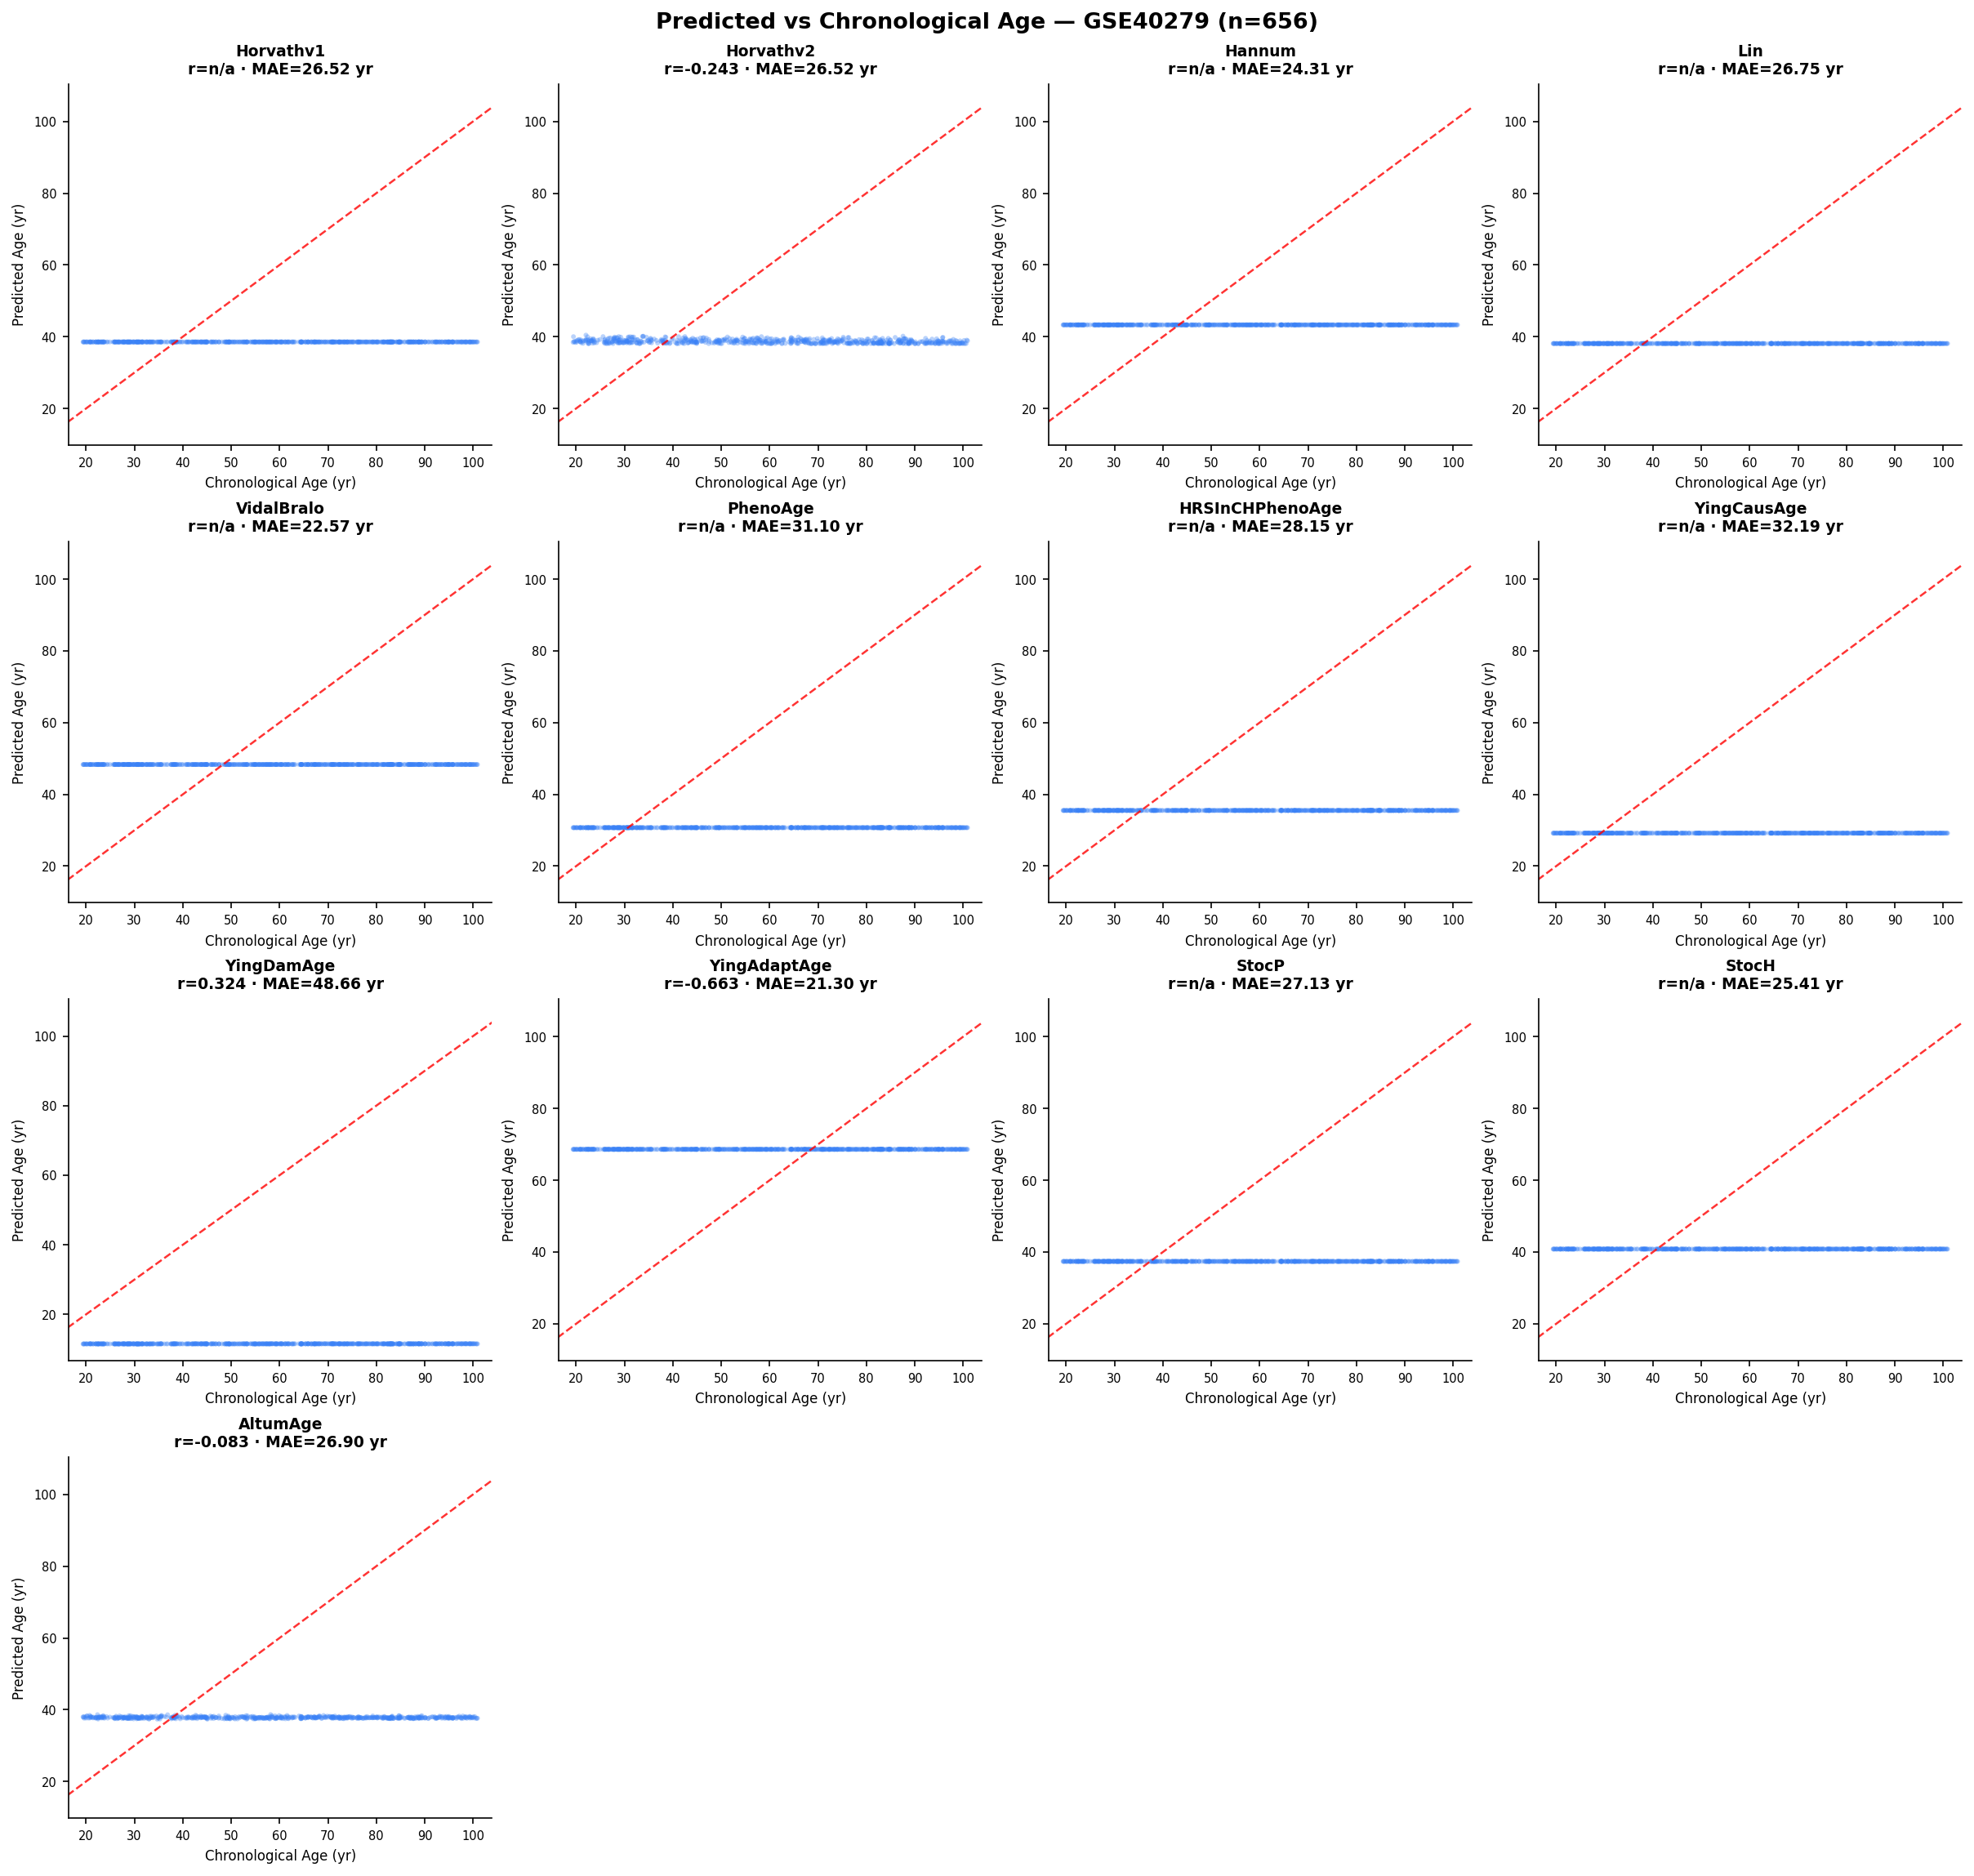

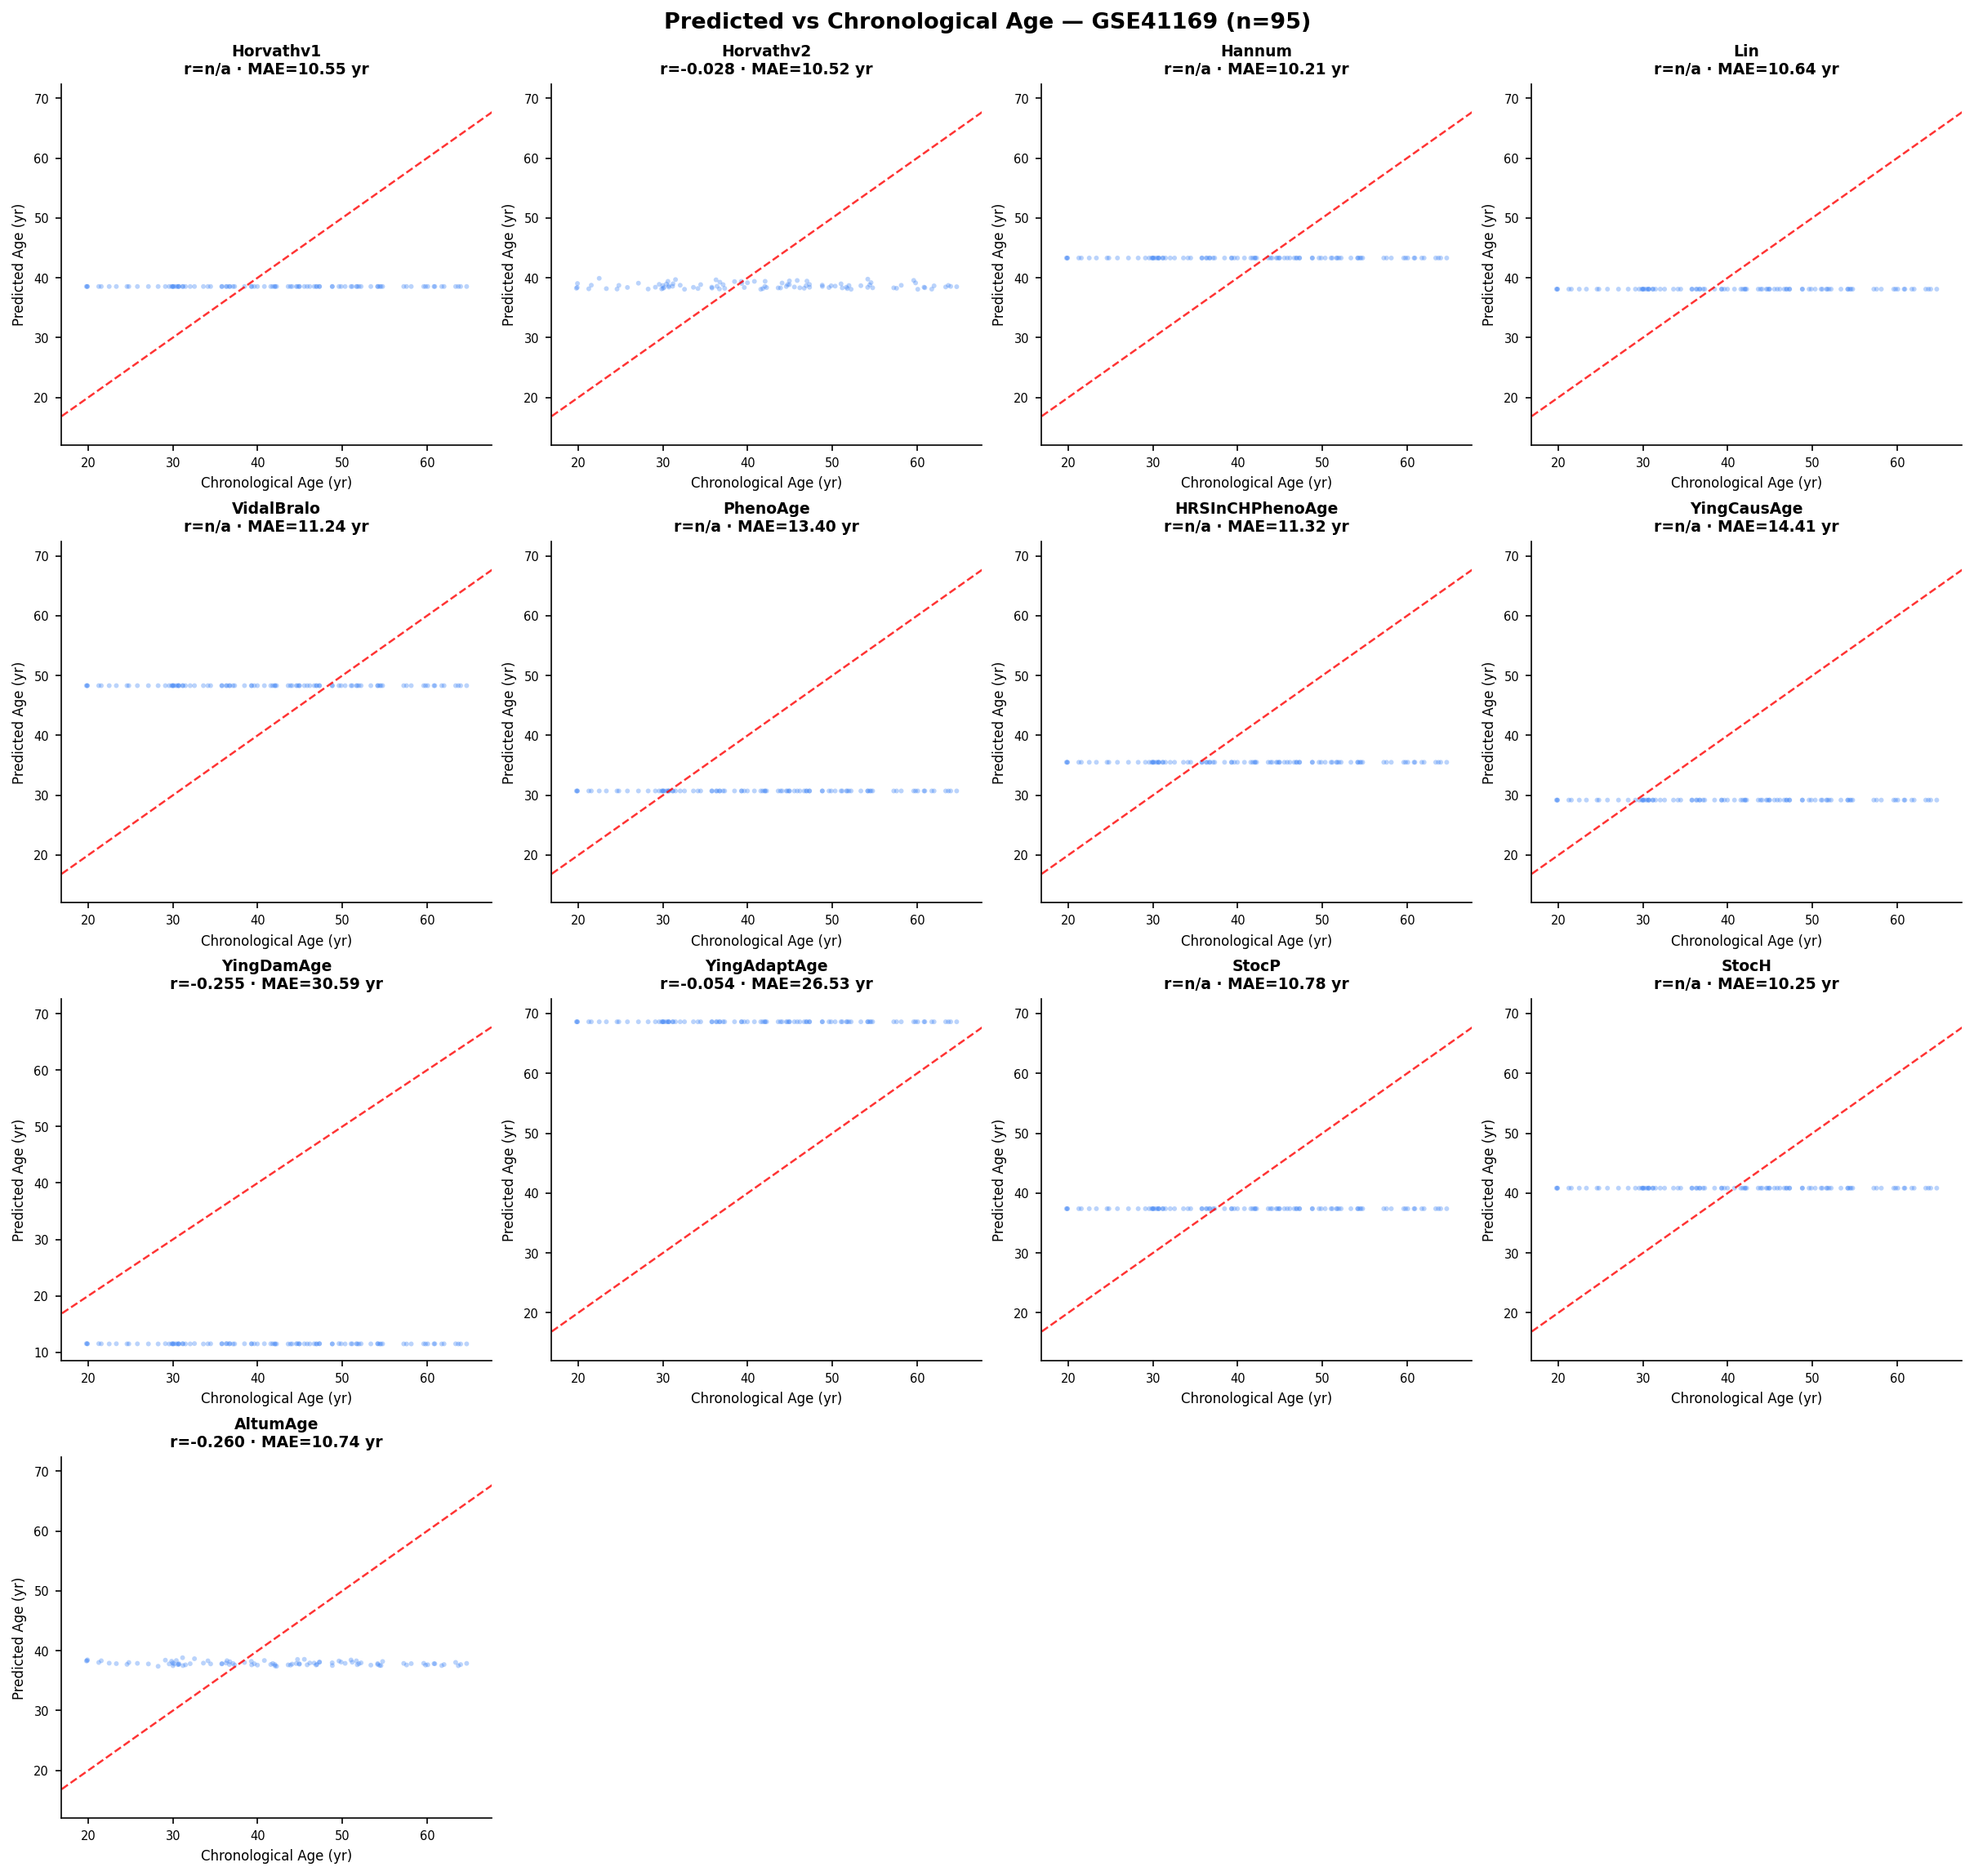

In [10]:
def plot_age_prediction_scatter(gse_id):
    true_ages = datasets[gse_id].metadata["age"].values.astype(float)
    n  = len(true_ages)
    mets = metrics_dfs[gse_id]
    clocks_to_plot = [c for c in AGE_CLOCKS
                      if all_results[gse_id].get(c) is not None]
    ncols = 4
    nrows = int(np.ceil(len(clocks_to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 4, nrows * 3.8),
                             constrained_layout=True)
    axes = axes.flatten()
    age_min, age_max = true_ages.min(), true_ages.max()
    for i, clock in enumerate(clocks_to_plot):
        ax    = axes[i]
        preds = all_results[gse_id][clock].values.astype(float)[:n]
        r   = mets.loc[clock, "r"]   if clock in mets.index else np.nan
        mae = mets.loc[clock, "mae"] if clock in mets.index else np.nan
        ax.scatter(true_ages, preds, alpha=0.35, s=8,
                   color="#3B82F6", edgecolors="none")
        diag = np.linspace(age_min - 5, age_max + 5, 100)
        ax.plot(diag, diag, "r--", lw=1.2, alpha=0.8)
        ax.set_xlim(age_min - 3, age_max + 3)
        ax.set_xlabel("Chronological Age (yr)", fontsize=8)
        ax.set_ylabel("Predicted Age (yr)", fontsize=8)
        ax.tick_params(labelsize=7)
        r_s   = f"{r:.3f}"   if not np.isnan(r)   else "n/a"
        mae_s = f"{mae:.2f}" if not np.isnan(mae) else "n/a"
        ax.set_title(f"{clock}\nr={r_s} · MAE={mae_s} yr",
                     fontsize=9, fontweight="bold")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"Predicted vs Chronological Age — {gse_id} (n={n})",
                 fontsize=13, fontweight="bold")
    path = os.path.join(FIGS_DIR, f"age_prediction_{gse_id}.png")
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

for gse_id in DATASET_IDS:
    plot_age_prediction_scatter(gse_id)


### V4 — MAE Comparison

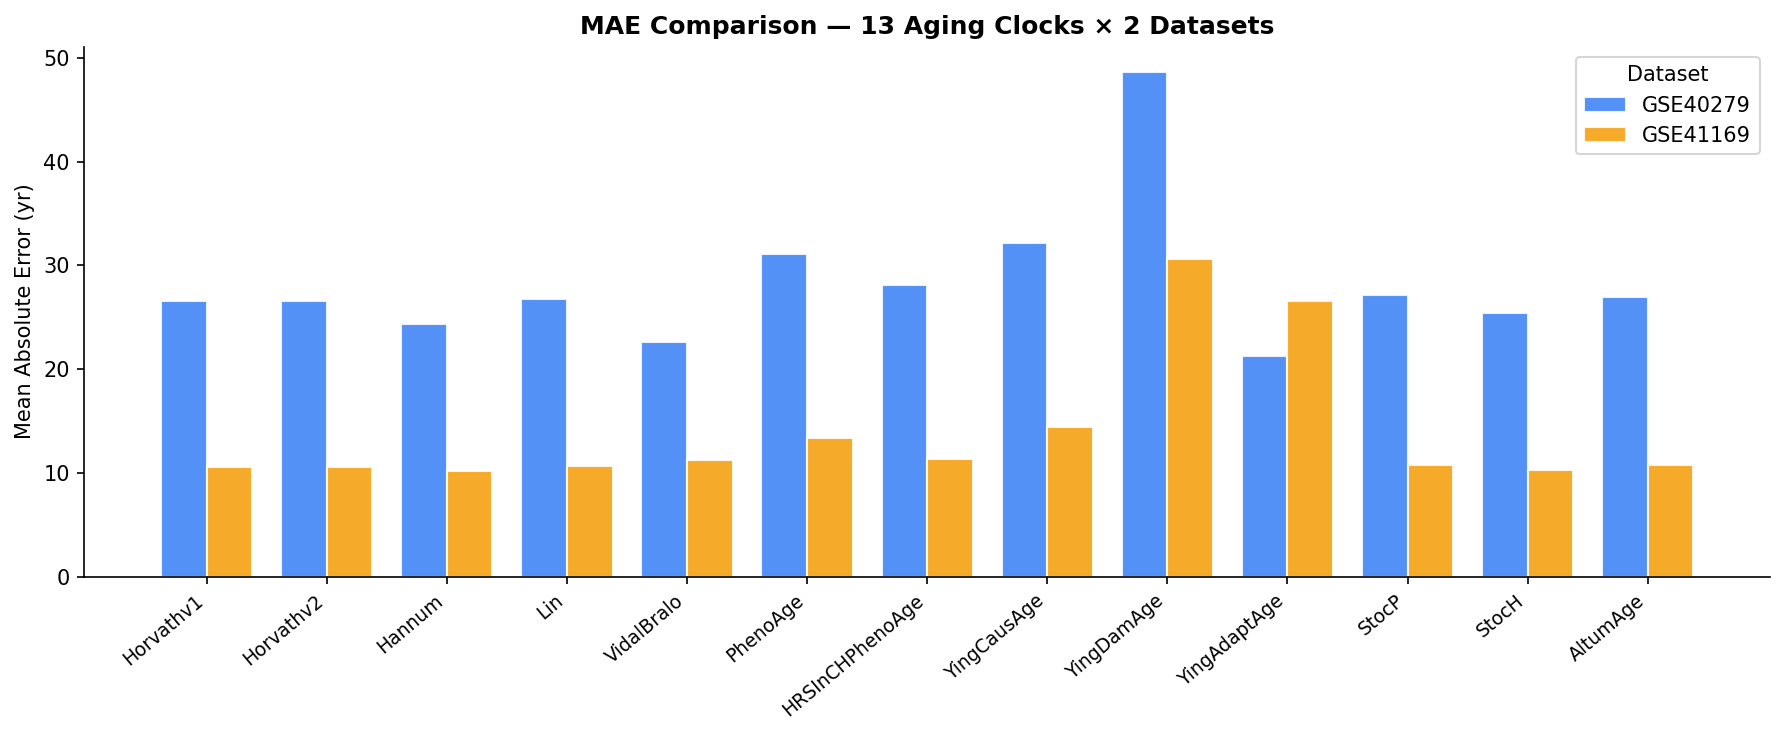

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))

mae_data = []
for gse_id in DATASET_IDS:
    for clock in AGE_CLOCKS:
        if clock in metrics_dfs[gse_id].index:
            v = metrics_dfs[gse_id].loc[clock, "mae"]
            if not np.isnan(v):
                mae_data.append({"Dataset": gse_id, "Clock": clock, "MAE (yr)": v})

mae_df  = pd.DataFrame(mae_data)
palette = {"GSE40279": "#3B82F6", "GSE41169": "#F59E0B"}
x, width = np.arange(len(AGE_CLOCKS)), 0.38

for idx, (gse_id, colour) in enumerate(palette.items()):
    sub  = mae_df[mae_df["Dataset"] == gse_id].set_index("Clock")
    vals = [sub.loc[c, "MAE (yr)"] if c in sub.index else 0 for c in AGE_CLOCKS]
    ax.bar(x + (idx - 0.5) * width, vals, width,
           label=gse_id, color=colour, alpha=0.88, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(AGE_CLOCKS, rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Mean Absolute Error (yr)")
ax.set_title("MAE Comparison — 13 Aging Clocks × 2 Datasets",
             fontsize=12, fontweight="bold")
ax.legend(title="Dataset")
plt.tight_layout()
path = os.path.join(FIGS_DIR, "mae_comparison.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()


### V5 — Predicted Age Distributions

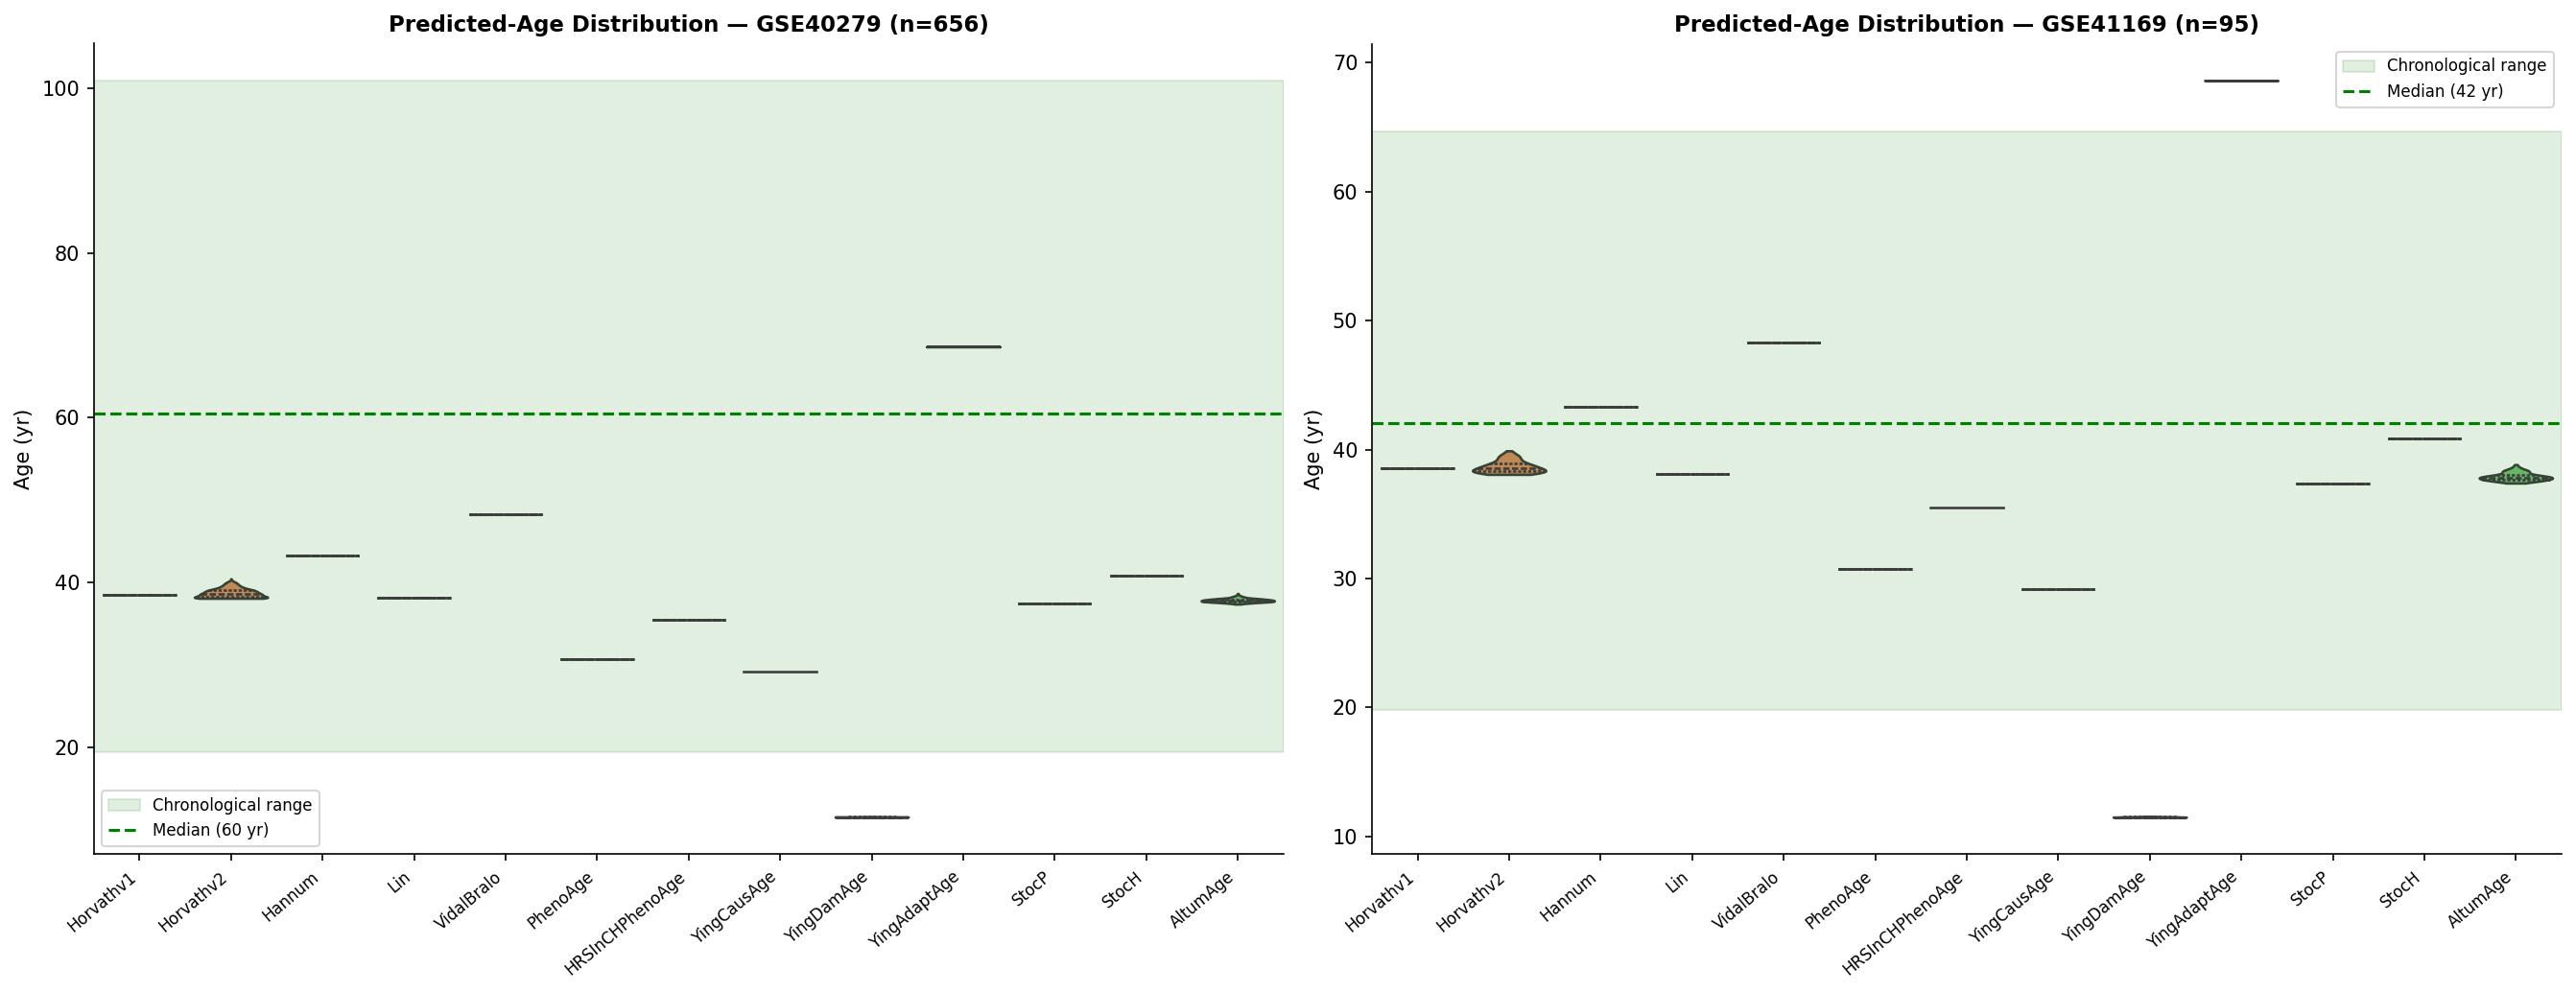

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_idx, gse_id in enumerate(DATASET_IDS):
    ax = axes[ax_idx]
    true_ages = datasets[gse_id].metadata["age"].values.astype(float)
    n = len(true_ages)
    rows = []
    for clock in AGE_CLOCKS:
        p = all_results[gse_id].get(clock)
        if p is None:
            continue
        for v in p.values.astype(float)[:n]:
            if not np.isnan(v):
                rows.append({"Clock": clock, "Predicted Age": v})
    pdf = pd.DataFrame(rows)
    sns.violinplot(data=pdf, x="Clock", y="Predicted Age",
                   inner="quartile", palette="muted",
                   cut=0, scale="width", ax=ax)
    ax.axhspan(true_ages.min(), true_ages.max(), alpha=0.12, color="green",
               label=f"Chronological range")
    ax.axhline(np.median(true_ages), color="green", linestyle="--",
               lw=1.5, label=f"Median ({np.median(true_ages):.0f} yr)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=8)
    ax.set_title(f"Predicted-Age Distribution — {gse_id} (n={n})",
                 fontsize=11, fontweight="bold")
    ax.set_ylabel("Age (yr)")
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.tight_layout()
path = os.path.join(FIGS_DIR, "predicted_age_distribution.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
plt.show()


### Summary Report

In [13]:
lines = [
    "# Epigenetics & Aging Analysis — Metrics Summary",
    "**Muhammad Taimoor Asad · 473749** · BI-436, NUST SINES · Spring 2026\n",
    "---\n",
]

for gse_id in DATASET_IDS:
    mets = metrics_dfs[gse_id]
    lines.append(f"## {gse_id} (n={datasets[gse_id].metadata.shape[0]})")
    lines.append("| Clock | Pearson r | MAE (yr) | Bias (yr) | RMSE (yr) |")
    lines.append("|-------|-----------|----------|-----------|-----------|")
    for clock in CLOCK_NAMES:
        if clock not in mets.index:
            lines.append(f"| {clock} | n/a | n/a | n/a | n/a |")
            continue
        row = mets.loc[clock]
        def fmt(v): return f"{v:.3f}" if not np.isnan(v) else "—"
        lines.append(f"| {clock} | {fmt(row['r'])} | {fmt(row['mae'])} "
                     f"| {fmt(row['bias'])} | {fmt(row['rmse'])} |")
    lines.append("")

summary_path = os.path.join(RESULTS_DIR, "summary.md")
with open(summary_path, "w") as f:
    f.write("\n".join(lines))

print(f"Saved → {summary_path}")
print("\n".join(lines))


Saved → results/summary.md
# Epigenetics & Aging Analysis — Metrics Summary
**Muhammad Taimoor Asad · 473749** · BI-436, NUST SINES · Spring 2026

---

## GSE40279 (n=656)
| Clock | Pearson r | MAE (yr) | Bias (yr) | RMSE (yr) |
|-------|-----------|----------|-----------|-----------|
| Horvathv1 | — | 26.520 | -21.640 | 32.110 |
| Horvathv2 | -0.243 | 26.520 | -21.470 | 32.090 |
| Hannum | — | 24.310 | -16.880 | 29.110 |
| Lin | — | 26.750 | -22.080 | 32.410 |
| VidalBralo | — | 22.570 | -11.860 | 26.520 |
| PhenoAge | — | 31.100 | -29.460 | 37.820 |
| HRSInCHPhenoAge | — | 28.150 | -24.670 | 34.220 |
| YingCausAge | — | 32.190 | -30.990 | 39.020 |
| YingDamAge | 0.324 | 48.660 | -48.660 | 54.130 |
| YingAdaptAge | -0.663 | 21.300 | 8.440 | 25.180 |
| StocP | — | 27.130 | -22.790 | 32.900 |
| StocH | — | 25.410 | -19.350 | 30.610 |
| AltumAge | -0.083 | 26.900 | -22.350 | 32.610 |
| DunedinPACE | -0.013 | 59.190 | -59.190 | 63.760 |

## GSE41169 (n=95)
| Clock | Pearson r | MAE (yr) |